In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as geopd
import matplotlib.pyplot as plt
import subprocess

## Config

In [2]:
DIR = "/home/dy23a.fsu/st/datasets/raw"
DIR = os.path.join(DIR, "Chicago")
TAXI_FILE = Path(DIR) / "chi_taxi_2025_15min.csv"
TNP_DIR = Path(DIR) / "TNP"
SCOOTER_FILE = Path(DIR) / "chi_scooter_2025_60min.csv"
BIKE_DIR = Path(DIR) / "bike"

FLOW_MODE = "arrival"  # arrival -> dropoff/end ; departure -> pickup/start
assert FLOW_MODE in {"arrival", "departure"}

AREAS_PATH = "./Chicago Community Areas.geojson"

OUT_DIR = Path(DIR)

# Sub-region filter analogous to NYC's borough filter.
# Set to a list of community area numbers (e.g. central area: [8, 28, 32, 33, 76]) to keep only those areas;
# leave as None / "all" to keep every community area.
TARGET_AREAS = None
TARGET_TAG = "central"  # filename tag used when TARGET_AREAS is set

In [3]:
YEAR = 2025
FREQ = "15min"
FREQ_SCOOTER = "60min"
TIME_START = pd.Timestamp(f"{YEAR}-01-01 00:00:00")
TIME_END = pd.Timestamp(f"{YEAR + 1}-01-01 00:00:00")

def make_grid(freq):
    steps = pd.date_range(TIME_START, TIME_END, freq=freq, inclusive="left")
    return steps, len(steps)

STEPS, T = make_grid(FREQ)
STEPS_SCOOTER, T_SCOOTER = make_grid(FREQ_SCOOTER)
FREQ_TAG = FREQ
FREQ_TAG_SCOOTER = FREQ_SCOOTER
print(f"YEAR={YEAR}, FREQ={FREQ} (T={T}), FREQ_SCOOTER={FREQ_SCOOTER} (T={T_SCOOTER}), FLOW_MODE={FLOW_MODE}")

YEAR=2025, FREQ=15min (T=35040), FREQ_SCOOTER=60min (T=8760), FLOW_MODE=arrival


## Shapefile and helpers

Region order follows the shapefile (sorted by community area number); all output `(N, T)` arrays use this same order.

In [4]:
areas = geopd.read_file(AREAS_PATH).to_crs("EPSG:4326")
areas["area_number"] = pd.to_numeric(areas["area_numbe"], errors="coerce").astype("Int64")
areas = areas.dropna(subset=["area_number"]).sort_values("area_number").reset_index(drop=True)
areas["region_idx"] = np.arange(len(areas), dtype=np.int32)
areas_for_join = areas[["region_idx", "geometry"]]
N = len(areas)
bounds = areas.total_bounds
area_to_region = {int(a): idx for idx, a in enumerate(areas["area_number"].astype(int).tolist())}
print(f"N={N} community areas, bbox={bounds}")

N=77 community areas, bbox=[-87.94011408  41.64454312 -87.5241371   42.02303859]


In [5]:
def make_step_idx_fn(freq, n_t):
    def fn(ts_series):
        ts = pd.to_datetime(ts_series, errors="coerce")
        step = ts.dt.floor(freq)
        delta = (step - TIME_START) / pd.Timedelta(freq)
        idx_float = delta.to_numpy(dtype=np.float64)
        valid = np.isfinite(idx_float) & (idx_float >= 0) & (idx_float < n_t)
        step_idx = np.zeros(len(idx_float), dtype=np.int64)
        step_idx[valid] = idx_float[valid].astype(np.int64)
        return step_idx, valid
    return fn

step_idx_15 = make_step_idx_fn(FREQ, T)
step_idx_60 = make_step_idx_fn(FREQ_SCOOTER, T_SCOOTER)

def map_points_to_regions(lon_arr, lat_arr, join_gdf, bounds_):
    minx, miny, maxx, maxy = bounds_
    region_idx = np.full(len(lon_arr), -1, dtype=np.int32)
    in_bbox = (
        (lon_arr >= minx)
        & (lon_arr <= maxx)
        & (lat_arr >= miny)
        & (lat_arr <= maxy)
    )
    if not np.any(in_bbox):
        return region_idx
    candidate_ids = np.where(in_bbox)[0]
    pts = geopd.GeoDataFrame(
        {"row_id": candidate_ids},
        geometry=geopd.points_from_xy(lon_arr[in_bbox], lat_arr[in_bbox]),
        crs="EPSG:4326",
    )
    joined = geopd.sjoin(pts, join_gdf, how="left", predicate="intersects")
    matched = joined.dropna(subset=["region_idx"]).drop_duplicates(subset=["row_id"], keep="first")
    region_idx[matched["row_id"].to_numpy(dtype=np.int64)] = matched["region_idx"].to_numpy(dtype=np.int32)
    return region_idx

def accumulate_nt(region_idx, step_idx, time_valid, nt_matrix, n_t):
    valid = time_valid & (region_idx >= 0)
    if not np.any(valid):
        return 0
    flat_idx = region_idx[valid].astype(np.int64) * n_t + step_idx[valid].astype(np.int64)
    binc = np.bincount(flat_idx, minlength=N * n_t)
    nt_matrix += binc.reshape(N, n_t)
    return int(valid.sum())

## Taxi

The Chicago taxi CSV already carries `pickup_community_area` / `dropoff_community_area`, so we map those integer area numbers directly to `region_idx` via the shapefile order.

In [6]:
def process_area_csv(path, area_col, time_col, step_idx_fn, n_t, chunksize=500_000):
    """For CSVs that already carry a community area column."""
    nt = np.zeros((N, n_t), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    print(f"Processing {path.name} [{area_col}, {time_col}]")
    reader = pd.read_csv(path, usecols=[area_col, time_col], chunksize=chunksize, low_memory=False)
    for chunk in reader:
        total_rows += len(chunk)
        chunk = chunk.dropna(subset=[area_col, time_col])
        if chunk.empty:
            continue
        area = pd.to_numeric(chunk[area_col], errors="coerce")
        valid_area = area.notna()
        if not valid_area.any():
            continue
        area = area[valid_area].astype(np.int64).reset_index(drop=True)
        ts = chunk.loc[valid_area, time_col].reset_index(drop=True)
        region_idx = area.map(area_to_region).fillna(-1).to_numpy(dtype=np.int32)
        step_idx, time_valid = step_idx_fn(ts)
        kept_rows += accumulate_nt(region_idx, step_idx, time_valid, nt, n_t)
    print(f"Rows seen: {total_rows:,}, kept in (N,T): {kept_rows:,}")
    return nt

In [7]:
if FLOW_MODE == "arrival":
    taxi_area_col, taxi_time_col = "dropoff_community_area", "trip_end_timestamp"
else:
    taxi_area_col, taxi_time_col = "pickup_community_area", "trip_start_timestamp"

if not TAXI_FILE.exists():
    raise FileNotFoundError(f"Taxi file not found: {TAXI_FILE}")
chi_taxi_nt = process_area_csv(TAXI_FILE, taxi_area_col, taxi_time_col, step_idx_15, T)
taxi_out = OUT_DIR / f"chi_taxi_{YEAR}_{FREQ_TAG}.npy"
np.save(taxi_out, chi_taxi_nt)
print(f"Saved {taxi_out} shape={chi_taxi_nt.shape}, total={chi_taxi_nt.sum():,}")

Processing chi_taxi_2025_15min.csv [dropoff_community_area, trip_end_timestamp]


Rows seen: 6,825,838, kept in (N,T): 6,238,498
Saved /home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_2025_15min.npy shape=(77, 35040), total=6,238,498


## TNP (Transportation Network Providers)

The TNP CSV uses the same `pickup_community_area` / `dropoff_community_area` schema as taxi but with a separate file. Sparsity / zero-rate is generally lower than taxi because TNP covers all of Chicago.

In [8]:
if FLOW_MODE == "arrival":
    tnp_area_col, tnp_time_col = "dropoff_community_area", "trip_end_timestamp"
else:
    tnp_area_col, tnp_time_col = "pickup_community_area", "trip_start_timestamp"

tnp_files = sorted(TNP_DIR.glob(f"chi_TNP_{YEAR}_*_15min.csv"))
if not tnp_files:
    raise FileNotFoundError(f"No TNP CSV files found under {TNP_DIR}")

chi_tnp_nt = np.zeros((N, T), dtype=np.int64)
for fp in tnp_files:
    chi_tnp_nt += process_area_csv(fp, tnp_area_col, tnp_time_col, step_idx_15, T)

tnp_out = OUT_DIR / f"chi_tnp_{YEAR}_{FREQ_TAG}.npy"
np.save(tnp_out, chi_tnp_nt)
print(f"Saved {tnp_out} shape={chi_tnp_nt.shape}, total={chi_tnp_nt.sum():,}")

Processing chi_TNP_2025_01_15min.csv [dropoff_community_area, trip_end_timestamp]


Rows seen: 7,607,290, kept in (N,T): 6,882,241
Processing chi_TNP_2025_02_15min.csv [dropoff_community_area, trip_end_timestamp]
Rows seen: 7,288,575, kept in (N,T): 6,606,861
Processing chi_TNP_2025_03_15min.csv [dropoff_community_area, trip_end_timestamp]
Rows seen: 8,037,030, kept in (N,T): 7,259,581
Processing chi_TNP_2025_04_15min.csv [dropoff_community_area, trip_end_timestamp]
Rows seen: 7,535,395, kept in (N,T): 6,721,286
Processing chi_TNP_2025_05_15min.csv [dropoff_community_area, trip_end_timestamp]
Rows seen: 8,087,664, kept in (N,T): 7,289,462
Processing chi_TNP_2025_06_15min.csv [dropoff_community_area, trip_end_timestamp]
Rows seen: 7,690,883, kept in (N,T): 6,905,478
Processing chi_TNP_2025_07_15min.csv [dropoff_community_area, trip_end_timestamp]
Rows seen: 8,039,804, kept in (N,T): 7,225,200
Processing chi_TNP_2025_08_15min.csv [dropoff_community_area, trip_end_timestamp]
Rows seen: 8,219,082, kept in (N,T): 7,388,608
Processing chi_TNP_2025_09_15min.csv [dropoff_comm

## Scooter

Chicago publishes scooter trips aggregated to **60-minute** bins (privacy preserving), so this mobility lives on its own `(N, T_SCOOTER)` grid and is **not** stacked into the 15-min merge below. Columns are `start_community_area_number` / `end_community_area_number` and `start_time` / `end_time`.

In [9]:
if FLOW_MODE == "arrival":
    scooter_area_col, scooter_time_col = "end_community_area_number", "end_time"
else:
    scooter_area_col, scooter_time_col = "start_community_area_number", "start_time"

if not SCOOTER_FILE.exists():
    raise FileNotFoundError(f"Scooter file not found: {SCOOTER_FILE}")
chi_scooter_nt = process_area_csv(SCOOTER_FILE, scooter_area_col, scooter_time_col, step_idx_60, T_SCOOTER)
scooter_out = OUT_DIR / f"chi_scooter_{YEAR}_{FREQ_TAG_SCOOTER}.npy"
np.save(scooter_out, chi_scooter_nt)
print(f"Saved {scooter_out} shape={chi_scooter_nt.shape}, total={chi_scooter_nt.sum():,}")

Processing chi_scooter_2025_60min.csv [end_community_area_number, end_time]


Rows seen: 9,452,755, kept in (N,T): 9,440,818
Saved /home/dy23a.fsu/st/datasets/raw/Chicago/chi_scooter_2025_60min.npy shape=(77, 8760), total=9,440,818


## Bike (gps -> shapefile)

Divvy CSVs only carry station lat/lon, so each trip endpoint is spatially joined to a community-area polygon. File pattern is `{YYYYMM}-divvy-tripdata.csv`.

In [10]:
def process_bike_csv(files, chunksize=500_000):
    nt = np.zeros((N, T), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    if FLOW_MODE == "arrival":
        lon_col, lat_col, time_col = "end_lng", "end_lat", "ended_at"
    else:
        lon_col, lat_col, time_col = "start_lng", "start_lat", "started_at"
    for fp in files:
        print(f"Processing {fp.name}")
        reader = pd.read_csv(
            fp,
            usecols=[lon_col, lat_col, time_col],
            chunksize=chunksize,
            low_memory=False,
        )
        for chunk in reader:
            total_rows += len(chunk)
            chunk = chunk.dropna(subset=[lon_col, lat_col, time_col])
            if chunk.empty:
                continue
            lon = pd.to_numeric(chunk[lon_col], errors="coerce").to_numpy(dtype=np.float64)
            lat = pd.to_numeric(chunk[lat_col], errors="coerce").to_numpy(dtype=np.float64)
            valid_xy = np.isfinite(lon) & np.isfinite(lat)
            if not np.any(valid_xy):
                continue
            lon = lon[valid_xy]
            lat = lat[valid_xy]
            ts = chunk.loc[valid_xy, time_col].reset_index(drop=True)
            step_idx, time_valid = step_idx_15(ts)
            region_idx = map_points_to_regions(lon, lat, areas_for_join, bounds)
            kept_rows += accumulate_nt(region_idx, step_idx, time_valid, nt, T)
    print(f"Rows seen: {total_rows:,}, kept in (N,T): {kept_rows:,}")
    return nt

bike_files = sorted(BIKE_DIR.glob(f"{YEAR}??-divvy-tripdata.csv"))
if not bike_files:
    raise FileNotFoundError(f"No Divvy bike CSV files found under {BIKE_DIR}")
chi_bike_nt = process_bike_csv(bike_files)
bike_out = OUT_DIR / f"chi_bike_{YEAR}_{FREQ_TAG}.npy"
np.save(bike_out, chi_bike_nt)
print(f"Saved {bike_out} shape={chi_bike_nt.shape}, total={chi_bike_nt.sum():,}")

Processing 202501-divvy-tripdata.csv


Processing 202502-divvy-tripdata.csv
Processing 202503-divvy-tripdata.csv
Processing 202504-divvy-tripdata.csv
Processing 202505-divvy-tripdata.csv
Processing 202506-divvy-tripdata.csv
Processing 202507-divvy-tripdata.csv
Processing 202508-divvy-tripdata.csv
Processing 202509-divvy-tripdata.csv
Processing 202510-divvy-tripdata.csv
Processing 202511-divvy-tripdata.csv
Processing 202512-divvy-tripdata.csv
Rows seen: 5,552,994, kept in (N,T): 5,446,548
Saved /home/dy23a.fsu/st/datasets/raw/Chicago/chi_bike_2025_15min.npy shape=(77, 35040), total=5,446,548


## Summary

In [11]:
def summarize_nt(name, arr):
    arr = np.asarray(arr)
    total = float(arr.sum())
    nnz = int(np.count_nonzero(arr))
    density = 100.0 * nnz / arr.size if arr.size else 0.0
    active_regions = int((arr.sum(axis=1) > 0).sum())
    active_steps = int((arr.sum(axis=0) > 0).sum())
    print(f"[{name}] total={total:,.0f}, nnz={nnz:,} ({density:.3f}%), "
          f"active_regions={active_regions}/{arr.shape[0]}, active_steps={active_steps}/{arr.shape[1]}")

for name, arr in [("taxi", chi_taxi_nt), ("tnp", chi_tnp_nt), ("bike", chi_bike_nt), ("scooter", chi_scooter_nt)]:
    summarize_nt(name, arr)

[taxi] total=6,238,498, nnz=1,030,202 (38.183%), active_regions=77/77, active_steps=35036/35040
[tnp] total=84,130,104, nnz=2,605,579 (96.572%), active_regions=77/77, active_steps=35036/35040
[bike] total=5,446,548, nnz=643,269 (23.842%), active_regions=77/77, active_steps=34904/35040
[scooter] total=9,440,818, nnz=464,903 (68.924%), active_regions=77/77, active_steps=8692/8760


## Filter by Community Areas

If `TARGET_AREAS` is a list of community area numbers, select the matching rows from each `(N, T)` array using the shapefile index, write `chi_<tag>_<mobility>_<year>_<freq>.npy`, and export the filtered region GeoJSON in the same order. Set `TARGET_AREAS=None` to keep all 77 areas.

In [12]:
if TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all"):
    target_set = {int(a) for a in TARGET_AREAS}
    mask = areas["area_number"].astype(int).isin(target_set)
    sel_idx = np.where(mask.to_numpy())[0]
    if sel_idx.size == 0:
        raise ValueError(f"No community areas matched TARGET_AREAS={TARGET_AREAS}")
    areas_sel = areas.iloc[sel_idx].reset_index(drop=True)
    area_tag = TARGET_TAG.lower().replace(" ", "_")
    geo_path = OUT_DIR / f"{area_tag}.geojson"
    areas_sel.drop(columns=["region_idx"], errors="ignore").to_file(geo_path, driver="GeoJSON")
    print(f"TARGET_AREAS={sorted(target_set)}, kept {len(sel_idx)}/{N} areas -> {geo_path}")
    for name, arr, freq_tag in [
        ("taxi", chi_taxi_nt, FREQ_TAG),
        ("tnp", chi_tnp_nt, FREQ_TAG),
        ("bike", chi_bike_nt, FREQ_TAG),
        ("scooter", chi_scooter_nt, FREQ_TAG_SCOOTER),
    ]:
        sub = arr[sel_idx]
        out = OUT_DIR / f"chi_{area_tag}_{name}_{YEAR}_{freq_tag}.npy"
        np.save(out, sub)
        print(f"  {out} shape={sub.shape}, total={sub.sum():,}")
else:
    sel_idx = np.arange(N)
    areas_sel = areas.copy()
    area_tag = "all"
    print(f"Area filter disabled, keeping all {N} community areas")

Area filter disabled, keeping all 77 community areas


## Merge mobilities

Stack any subset of the **15-min** mobilities `["taxi", "tnp", "bike"]` into a single `(M, N, T)` array. Scooter is on a 60-min grid and is therefore not part of this merge.

In [13]:
MERGE_MOBILITIES = ["taxi", "tnp", "bike"]
MOBILITY_ARRS = {"taxi": chi_taxi_nt, "tnp": chi_tnp_nt, "bike": chi_bike_nt}
missing = [m for m in MERGE_MOBILITIES if m not in MOBILITY_ARRS]
if missing:
    raise ValueError(f"Unknown mobilities in MERGE_MOBILITIES: {missing}")

merged = np.stack([MOBILITY_ARRS[m] for m in MERGE_MOBILITIES], axis=1)
merged_tag = "_".join(MERGE_MOBILITIES)
merged_out = OUT_DIR / f"chi_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
np.save(merged_out, merged)
print(f"{merged_out} shape={merged.shape} (N,M,T)")

if TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all"):
    merged_a = merged[sel_idx, :, :]
    merged_a_out = OUT_DIR / f"chi_{area_tag}_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    np.save(merged_a_out, merged_a)
    print(f"{merged_a_out} shape={merged_a.shape} (N,M,T)")

/home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_tnp_bike_2025_15min.npy shape=(77, 3, 35040) (N,M,T)


## Visualization & Sparsity Report

For each mobility:
- **Heatmap**: total flow per community area painted on the shapefile (full city + filtered subset if `TARGET_AREAS` is set).
- **Sparsity report**: zero-rate over `(N,T)`, dead regions, dead steps, per-region/per-step quantiles.
- **Temporal panels**: daily total flow + weekday x hour heatmap.

Each mobility's panel uses its own time grid (15-min for taxi/tnp/bike, 60-min for scooter).

In [14]:
MOBILITY_VIZ = [
    ("taxi", chi_taxi_nt, STEPS),
    ("tnp", chi_tnp_nt, STEPS),
    ("bike", chi_bike_nt, STEPS),
    ("scooter", chi_scooter_nt, STEPS_SCOOTER),
]

def plot_area_heat(area_gdf, values, title, cmap="YlOrRd", log=True):
    plot_gdf = area_gdf.copy()
    vals = np.asarray(values, dtype=np.float64)
    if log:
        plot_gdf["flow"] = np.log1p(vals)
        legend_label = "log1p(total flow)"
    else:
        plot_gdf["flow"] = vals
        legend_label = "total flow"
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    plot_gdf.plot(
        column="flow",
        cmap=cmap,
        linewidth=0.2,
        edgecolor="black",
        legend=True,
        legend_kwds={"label": legend_label, "shrink": 0.6},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def sparsity_report(name, arr, time_index):
    arr = np.asarray(arr)
    total_cells = arr.size
    nnz = int(np.count_nonzero(arr))
    zero_rate = 1.0 - nnz / total_cells if total_cells else 0.0
    total_flow = float(arr.sum())
    region_sum = arr.sum(axis=1)
    step_sum = arr.sum(axis=0)
    dead_regions = int((region_sum == 0).sum())
    dead_steps = int((step_sum == 0).sum())
    region_q = np.quantile(region_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    step_q = np.quantile(step_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    nz_step_q = np.quantile(step_sum[step_sum > 0], [0.25, 0.5, 0.75]) if (step_sum > 0).any() else np.array([0, 0, 0])
    print(f"=== Sparsity report: {name} ===")
    print(f"  shape={arr.shape}, total_flow={total_flow:,.0f}")
    print(f"  nnz cells={nnz:,}/{total_cells:,}  zero_rate={zero_rate*100:.3f}%")
    print(f"  dead regions={dead_regions}/{arr.shape[0]}  dead steps={dead_steps}/{arr.shape[1]}")
    print(f"  region totals  min/Q1/med/Q3/max = {region_q[0]:,.0f} / {region_q[1]:,.0f} / {region_q[2]:,.0f} / {region_q[3]:,.0f} / {region_q[4]:,.0f}")
    print(f"  step totals    min/Q1/med/Q3/max = {step_q[0]:,.0f} / {step_q[1]:,.0f} / {step_q[2]:,.0f} / {step_q[3]:,.0f} / {step_q[4]:,.0f}")
    print(f"  step totals  (non-zero only) Q1/med/Q3 = {nz_step_q[0]:,.0f} / {nz_step_q[1]:,.0f} / {nz_step_q[2]:,.0f}")
    idx_active = np.where(step_sum > 0)[0]
    if idx_active.size:
        print(f"  first_active={pd.Timestamp(time_index[idx_active[0]])}, last_active={pd.Timestamp(time_index[idx_active[-1]])}")

def plot_temporal_panels(name, arr, time_index):
    arr = np.asarray(arr)
    ts = pd.to_datetime(time_index)
    series = pd.Series(arr.sum(axis=0), index=ts)
    daily = series.resample("D").sum()
    hod = pd.DataFrame({"flow": series.values}, index=ts)
    hod["dow"] = hod.index.dayofweek
    hod["hour"] = hod.index.hour
    pivot = hod.pivot_table(index="dow", columns="hour", values="flow", aggfunc="sum").reindex(index=range(7), columns=range(24))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(daily.index, daily.values, linewidth=1.2)
    axes[0].set_title(f"{name} - daily total flow")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Daily total flow")
    axes[0].grid(alpha=0.25)
    im = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis", origin="lower")
    axes[1].set_title(f"{name} - weekday x hour total flow")
    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("Day of week (0=Mon)")
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_yticks(range(7))
    axes[1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="flow")
    plt.tight_layout()
    plt.show()

=== Sparsity report: taxi ===
  shape=(77, 35040), total_flow=6,238,498
  nnz cells=1,030,202/2,698,080  zero_rate=61.817%
  dead regions=0/77  dead steps=4/35040
  region totals  min/Q1/med/Q3/max = 1,120 / 6,641 / 14,166 / 43,524 / 1,653,136
  step totals    min/Q1/med/Q3/max = 0 / 59 / 180 / 277 / 512
  step totals  (non-zero only) Q1/med/Q3 = 59 / 180 / 277
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


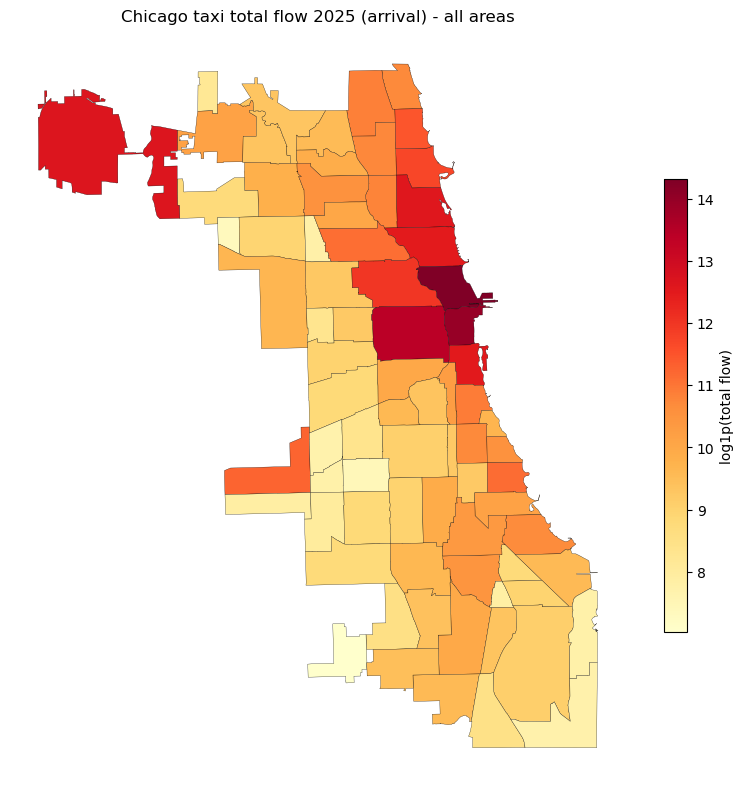

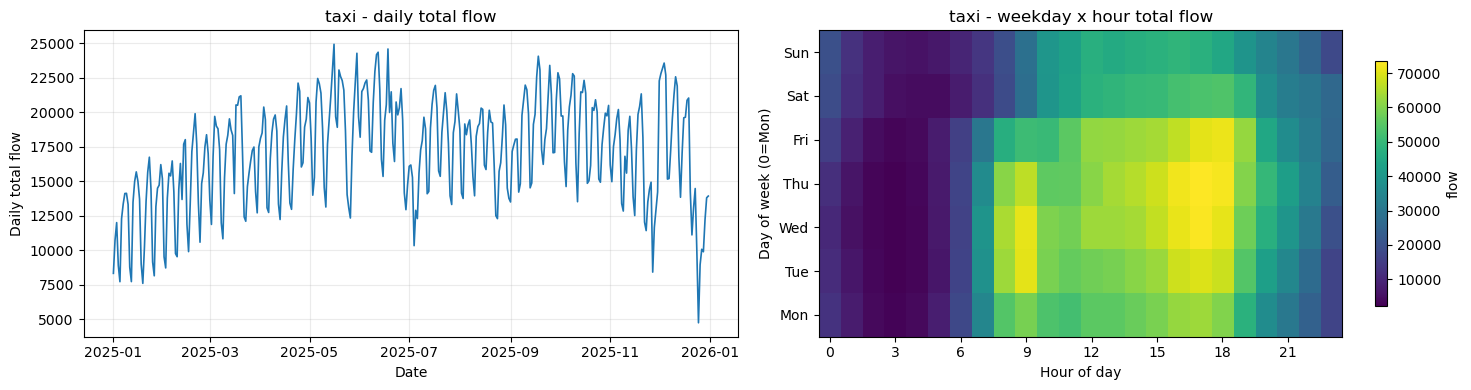

=== Sparsity report: tnp ===
  shape=(77, 35040), total_flow=84,130,104
  nnz cells=2,605,579/2,698,080  zero_rate=3.428%
  dead regions=0/77  dead steps=4/35040
  region totals  min/Q1/med/Q3/max = 50,867 / 218,504 / 456,187 / 821,650 / 12,133,704
  step totals    min/Q1/med/Q3/max = 0 / 1,440 / 2,549 / 3,072 / 7,163
  step totals  (non-zero only) Q1/med/Q3 = 1,440 / 2,550 / 3,072
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


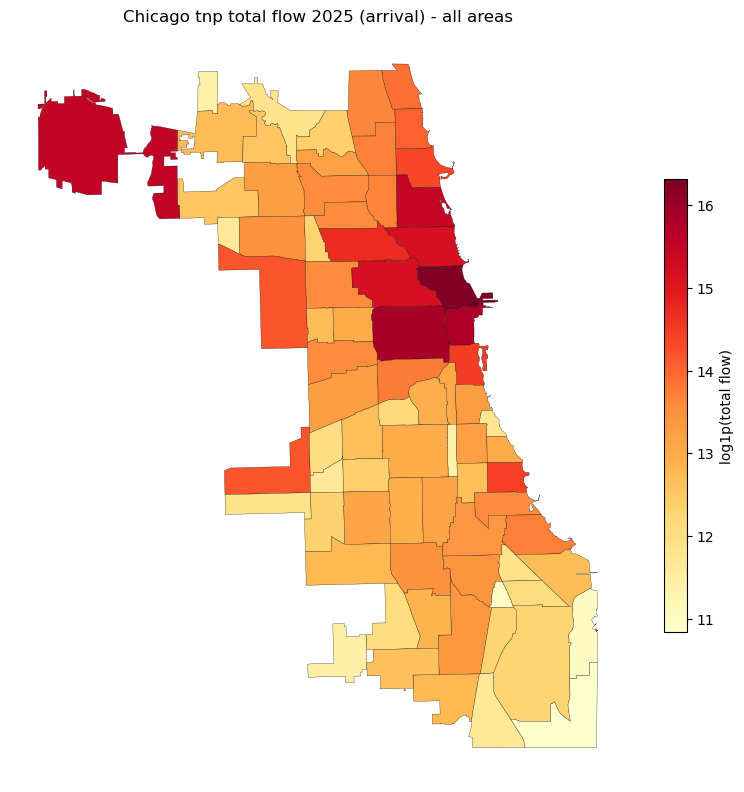

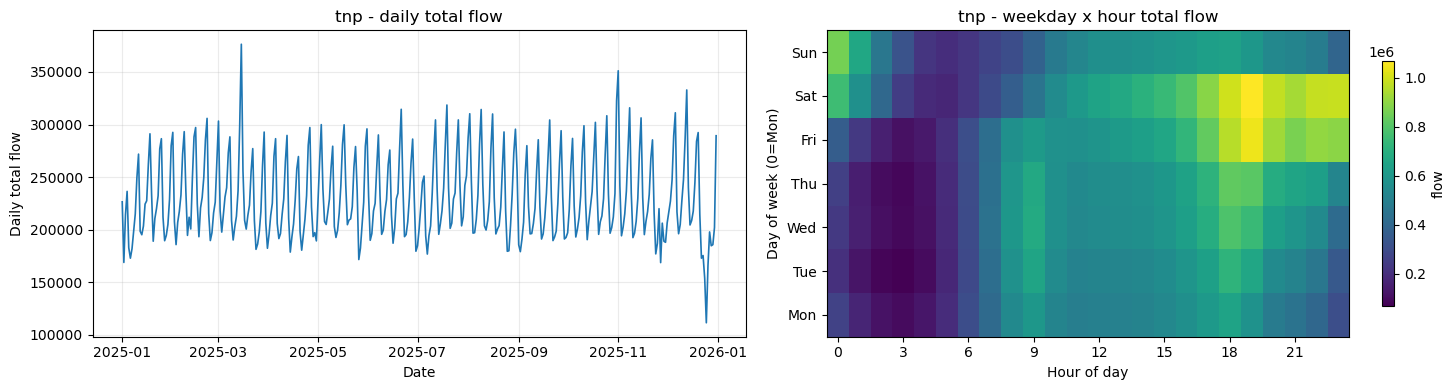

=== Sparsity report: bike ===
  shape=(77, 35040), total_flow=5,446,548
  nnz cells=643,269/2,698,080  zero_rate=76.158%
  dead regions=0/77  dead steps=136/35040
  region totals  min/Q1/med/Q3/max = 63 / 1,155 / 3,933 / 29,703 / 1,115,010
  step totals    min/Q1/med/Q3/max = 0 / 30 / 97 / 236 / 922
  step totals  (non-zero only) Q1/med/Q3 = 30 / 97 / 236
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


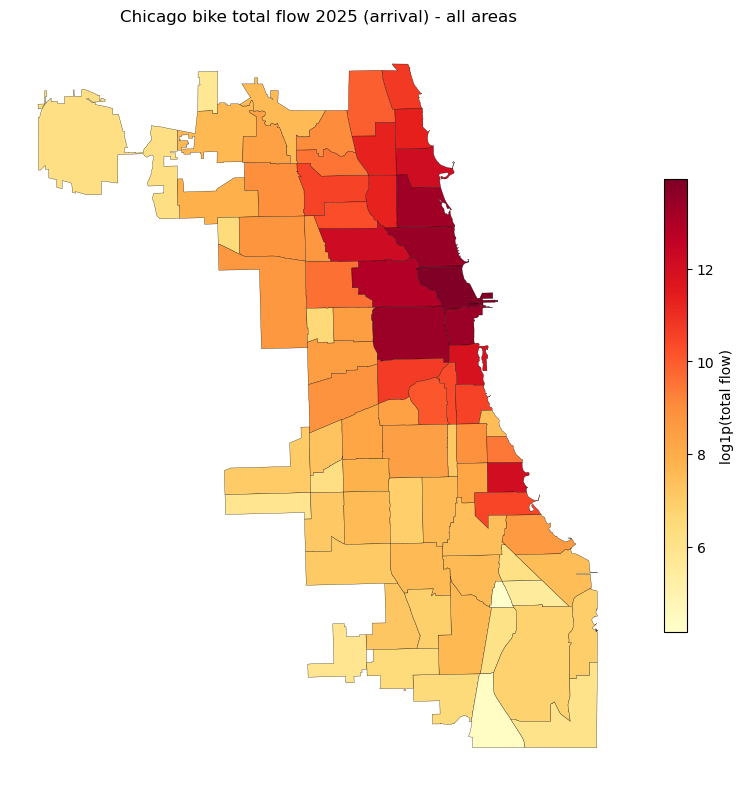

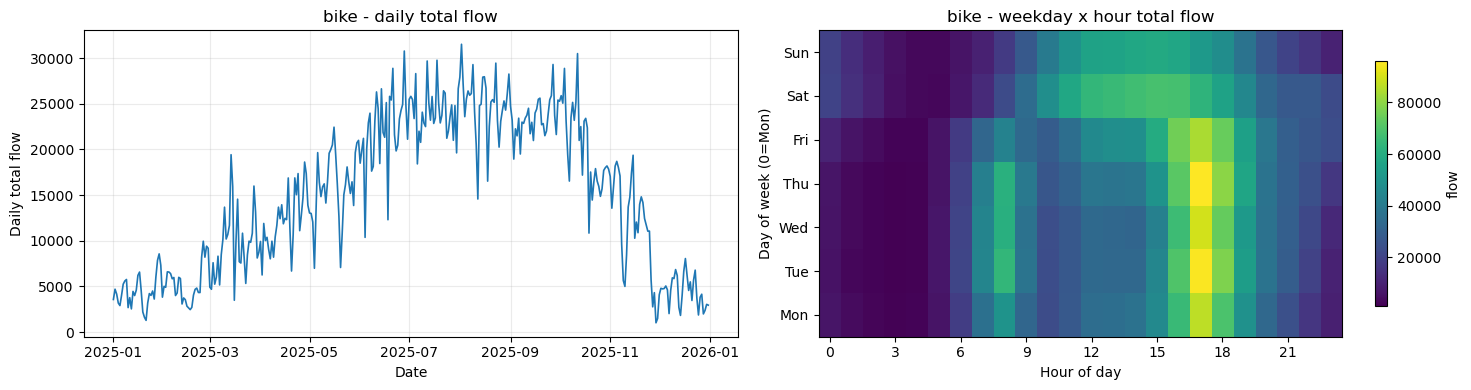

=== Sparsity report: scooter ===
  shape=(77, 8760), total_flow=9,440,818
  nnz cells=464,903/674,520  zero_rate=31.076%
  dead regions=0/77  dead steps=68/8760
  region totals  min/Q1/med/Q3/max = 667 / 25,523 / 57,076 / 114,531 / 887,692
  step totals    min/Q1/med/Q3/max = 0 / 143 / 656 / 1,770 / 4,905
  step totals  (non-zero only) Q1/med/Q3 = 153 / 668 / 1,781
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 01:00:00


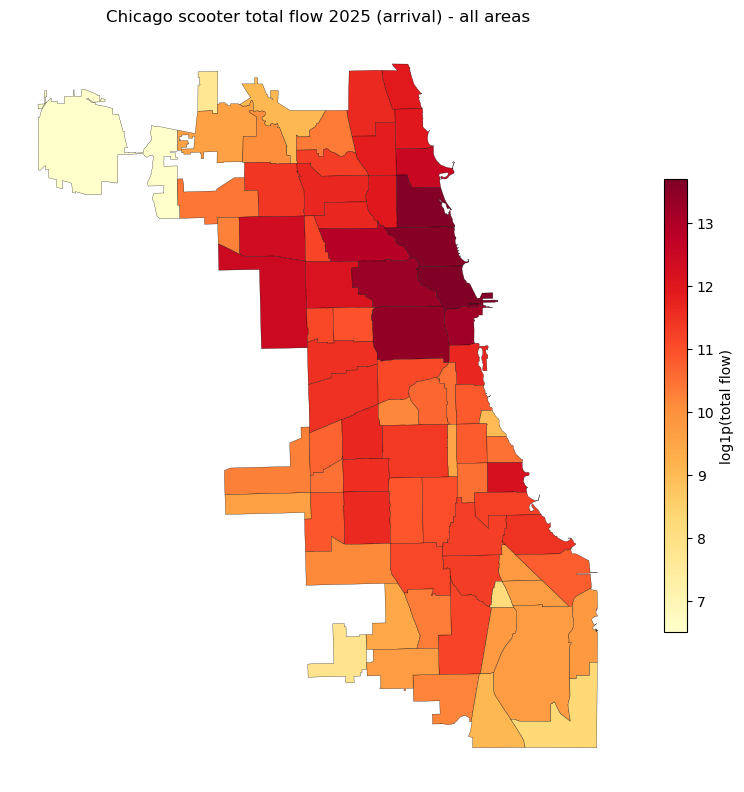

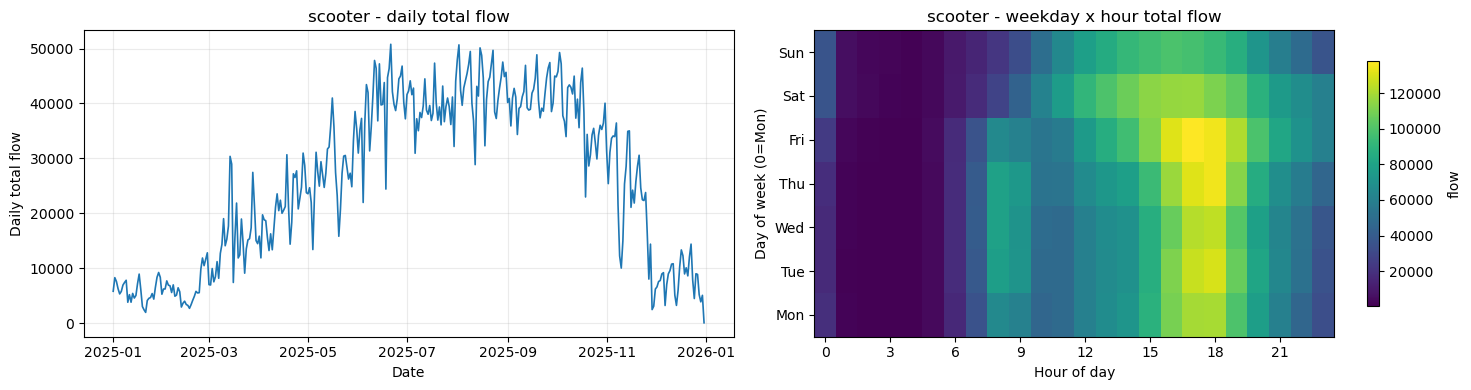

In [15]:
area_active = TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all")
for name, arr, time_index in MOBILITY_VIZ:
    sparsity_report(name, arr, time_index)
    plot_area_heat(areas, arr.sum(axis=1), f"Chicago {name} total flow {YEAR} ({FLOW_MODE}) - all areas")
    if area_active:
        sub = arr[sel_idx]
        sparsity_report(f"{name} [{TARGET_TAG}]", sub, time_index)
        plot_area_heat(areas_sel, sub.sum(axis=1), f"Chicago {name} total flow {YEAR} ({FLOW_MODE}) - {TARGET_TAG}")
    plot_temporal_panels(name, arr, time_index)

In [16]:
if TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all"):
    src_path = OUT_DIR / f"chi_{area_tag}_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    DATASET = f"chicago_{area_tag}_15min"
else:
    src_path = OUT_DIR / f"chi_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    DATASET = "chicago_15min"

merged_arr = np.load(src_path)
M = len(MERGE_MOBILITIES)
if merged_arr.shape[0] == M and merged_arr.shape[1] != M:
    ndt = merged_arr.transpose(1, 0, 2)   # (M, N, T) -> (N, D, T)
elif merged_arr.shape[1] == M:
    ndt = merged_arr                       # already (N, D, T)
else:
    raise ValueError(f"Cannot locate mobility axis (M={M}) in {merged_arr.shape}")
ndt_path = src_path.with_name(src_path.stem + "_NDT.npy")
np.save(ndt_path, ndt)
print(f"{ndt_path} shape={tuple(ndt.shape)} (N, D, T) with D={M} mobilities")

for hy in [1, 3, 6, 9, 12]:
    subprocess.run([
        "python3", "/home/dy23a.fsu/st/utils/generate.py",
        "--data_path", str(ndt_path),
        "--fmt", "NDT",
        "--clip_neg",
        "--per_channel",
        "--log1p",
        "--dataset", DATASET,
        "--years", f"{YEAR}_12to{hy}",
        "--seq_length_x", "12",
        "--seq_length_y", str(hy),
    ], check=True)


/home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_tnp_bike_2025_15min_NDT.npy shape=(77, 3, 35040) (N, D, T) with D=3 mobilities


Loaded /home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_tnp_bike_2025_15min_NDT.npy, raw shape: (77, 3, 35040)
Clipped negative values to 0
Reordered NDT → TND, shape: (35040, 77, 3)
Raw — max: 1443, min: 0, mean: 11.8374, std: 43.7326
Index range: [11, 35039), total=35028, train=28022, val=3503, test=3503
MinMaxScaler(log1p=True) min: [0.0, 0.0, 0.0], max: [5.181783676147461, 7.275172233581543, 5.446737289428711]
Normalized — max: 1.0000, min: 0.0000, mean: 0.1724, std: 0.2060
Saved meta.json to /blue/gtyson.fsu/dy23a.fsu/datasets/chicago_15min/2025_12to1/meta.json
Saved to /blue/gtyson.fsu/dy23a.fsu/datasets/chicago_15min/2025_12to1
Saved info.json to /blue/gtyson.fsu/dy23a.fsu/datasets/chicago_15min/2025_12to1/info.json
Loaded /home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_tnp_bike_2025_15min_NDT.npy, raw shape: (77, 3, 35040)
Clipped negative values to 0
Reordered NDT → TND, shape: (35040, 77, 3)
Raw — max: 1443, min: 0, mean: 11.8374, std: 43.7326
Index range: [11, 35037), total

CompletedProcess(args=['python3', '/home/dy23a.fsu/st/utils/generate.py', '--data_path', '/home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_tnp_bike_2025_15min_NDT.npy', '--fmt', 'NDT', '--clip_neg', '--per_channel', '--log1p', '--dataset', 'chicago_15min', '--years', '2025_12to12', '--seq_length_x', '12', '--seq_length_y', '12'], returncode=0)

In [17]:
sys.path.insert(0, "/home/dy23a.fsu/st/utils")
from get_adj_mat import get_adjacency_matrix

if TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all"):
    ADJ_OUT = Path("/home/dy23a.fsu/st/datasets") / f"chicago_{area_tag}_15min" / f"{TARGET_TAG}.npy"
    ADJ_OUT.parent.mkdir(parents=True, exist_ok=True)
    ctr = areas_sel.set_geometry("geometry").centroid.reset_index(drop=True)
    N_adj = len(ctr)
    ids = list(range(N_adj))
    distance = [[i, j, ctr[i].distance(ctr[j])] for i in ids for j in ids]
    adj_mx = get_adjacency_matrix(distance_df=distance, sensor_ids=ids)
    np.save(ADJ_OUT, adj_mx)
    print(f"Saved {ADJ_OUT} shape={adj_mx.shape}")

else:
    ADJ_OUT = Path("/home/dy23a.fsu/st/datasets") / "chicago_15min" / "chicago.npy"
    ADJ_OUT.parent.mkdir(parents=True, exist_ok=True)
    ctr = areas.set_geometry("geometry").centroid.reset_index(drop=True)
    N_adj = len(ctr)
    ids = list(range(N_adj))
    distance = [[i, j, ctr[i].distance(ctr[j])] for i in ids for j in ids]
    adj_mx = get_adjacency_matrix(distance_df=distance, sensor_ids=ids)
    np.save(ADJ_OUT, adj_mx)
    print(f"Saved {ADJ_OUT} shape={adj_mx.shape}")

Saved /home/dy23a.fsu/st/datasets/chicago_15min/chicago.npy shape=(77, 77)


/scratch/local/35780621/ipykernel_2364593/2163899904.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ctr = areas.set_geometry("geometry").centroid.reset_index(drop=True)
